# Dirichlet Process for Bayesian Nonparametrics
In the nonparametric setting, we have undecided, unbounded $K.$ We implement the Chinese Restaurant process as well as the stick-breaking process.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

## Data generation
*The following code will be constant across the three notebooks.*

We pretend that the data is generated according to $$\pi\sim\text{Dir}(\alpha_1,\dots,\alpha_K)$$ $$z_i\sim\text{Cat}(\pi)$$ $$x_i|z_i=k \sim \mathcal{N}(\mu_k,I)$$ where we treat $K,\alpha_k$ as hyperparameters with hidden $\mu_k.$

In [2]:
# Hyperparameters
np.random.seed(14) # for reproducibility
K = 8 # number of clusters
alpha = np.random.choice(range(1,11), K) # hyperparameter for dirichlet distribution
N = 250 # number of data points
mu = np.random.uniform(-10, 10, (K, 2)) # cluster means
sigma = np.array([np.eye(2) for i in range(K)]) # cluster covariances

# Parameters for Gaussian Mixture Model
pi = np.random.dirichlet(alpha) # mixing proportions
z = np.random.choice(K, N, p=pi) # cluster assignments

# Generate data points
x = np.array([np.random.multivariate_normal(mu[z[i]], sigma[z[i]]) for i in range(N)]) # data points

In [3]:
def visualize(x, z, iter):
    """
    Visualize the GMM with the current parameters
    """
    plt.scatter(x[:, 0], x[:, 1], c=z, cmap='viridis', s=50)
    plt.title(f'GMM at iteration {iter}')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.colorbar(label='Cluster Assignment')
    plt.show()

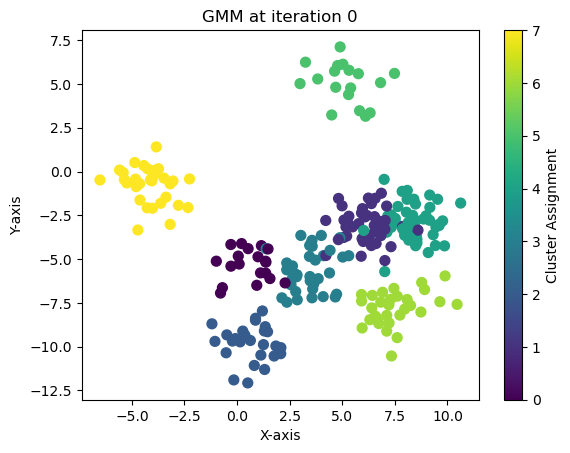

In [4]:
# Visualize the data
visualize(x, z, 0)

## Nonparametric Gibbs Sampling
### Overview
In the nonparametric setting, we do not define a number of clusters $K.$ Instead, we use a Dirichlet process, which allows us to have infinite cluster centers. We perform Gibbs sampling from its prior distribution, described by the Chinese Restaurant Process.
### Chinese Restaurant Process
The Chinese Restaurant Process (CRP) defines our prior. Given $n$ data-points processed already sorted into $K$ clusters, with hyperparameter $\alpha$, then we say that $$p(z_{n+1}) = \begin{cases} \frac{n_k}{\alpha+n}\text{ if $k\leq K$} \\  \frac{\alpha}{\alpha+n}\text{ else}\end{cases}$$ However, note that this does not depend on $\theta.$ Hence, $$p(z_i|\theta)=p(z_i).$$
### Nonparametric Setting
Recall that in the parametric case, we sought $$p(z_i,\theta,\pi|x_i).$$ But in the *non*parametric setting, we would like to get rid of these parameters. We instead seek $p(z_i|z_i)$ directly. Hence, we have $$p(z_i|x_i)\propto p(x_i|z_i)p(z_i).$$
### Collapsed Gibbs Sampling
When conducting Gibbs sampling, we iterate over each datapoint: $$p(z_i|z_{-i})=\text{CRP}(z_{-i})=\begin{cases} \frac{n_k-1}{N+\alpha-1}\text{ if $k\leq K$} \\ \frac{\alpha}{n_k+\alpha-1}\text{ else}\end{cases}.$$
For $p(x_i|z_i=k,z_{-i},x_{-i}),$ we have $$p(x_i|z_i=k,z_{-i},x_{-i})=\mathcal{N}(\mu',\tau'+\sigma^2)$$ where $$\mu' = \frac{\frac{n_k\bar x_k}{\sigma^2} + \frac{\mu_0}{\tau_0}}{\frac{n_k}{\sigma^2} + \frac{1}{\tau_0}}$$ and $$\tau' = \frac{1}{\frac{n_k}{\sigma^2} + \frac{1}{\tau_0}}$$
where $\mu_0,\tau_0, \sigma^2$ are hyperparameters and $\bar x_k$ is the sample mean.

In [37]:
np.random.seed(14) # for reproducibility
# Hyperparameters
alpha_hat = 50
var_hat = 0.2*np.eye(2)
mu0 = np.zeros(2)
tau0 = 0.1*np.eye(2)

In [38]:
def collapsed_gibbs(x, alpha_hat, var_hat, mu0, tau0, N, clusters):
    """
    Collapsed Gibbs sampling for GMM
    """
    for i in range(N):
        # Remove the current point from the cluster
        clusters_rest = np.delete(clusters, i)
        x_rest = np.delete(x, i, axis=0)

        # Chinese Remainder Process
        n_k = np.bincount(clusters_rest)
        CRP = np.append(n_k, alpha_hat)
        CRP = CRP / (N - 1 + alpha_hat)

        # Posteriors
        post = np.zeros(len(CRP))
        for k in range(len(CRP) - 1):
            if n_k[k] == 0:
                continue
            x_k = x_rest[clusters_rest == k]
            n_k_k = x_k.shape[0]
            xbar_k = np.mean(x_k, axis=0)

            tau0_inv = np.linalg.inv(tau0)
            var_hat_inv = np.linalg.inv(var_hat)

            tau_prime = np.linalg.inv(n_k_k * var_hat_inv + tau0_inv)
            mu_prime = tau_prime @ (n_k_k * var_hat_inv @ xbar_k + tau0_inv @ mu0)
            
            predictive_cov = tau_prime + var_hat
            post[k] = CRP[k] * multivariate_normal.pdf(x[i], mean=mu_prime, cov=predictive_cov)
        post[-1] = CRP[-1] * multivariate_normal.pdf(x[i], mean=mu0, cov=tau0 + var_hat)


        # Draw a new cluster assignment
        clusters[i] = np.random.choice(len(post), p=post / np.sum(post))
        
    return clusters

## Results

We visualize the results of EM at different stages.

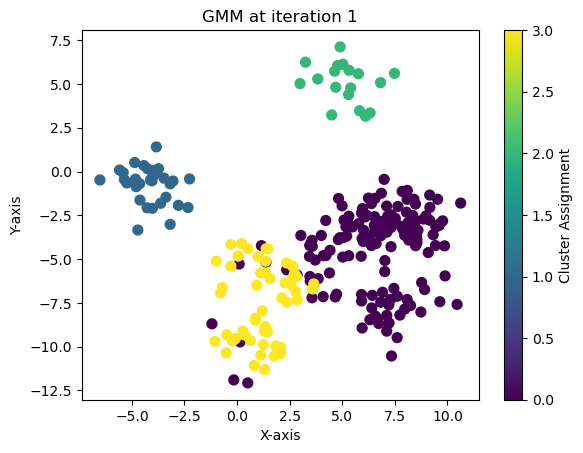

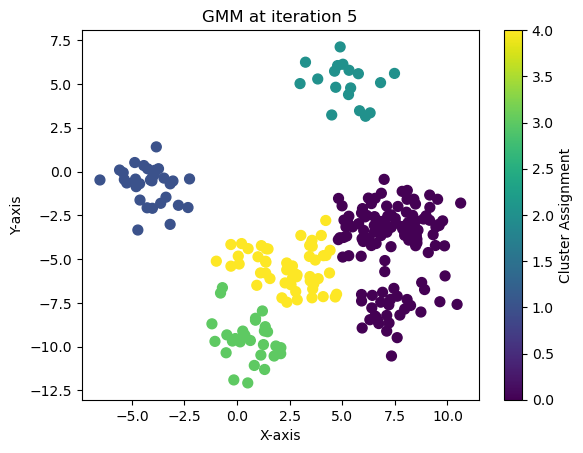

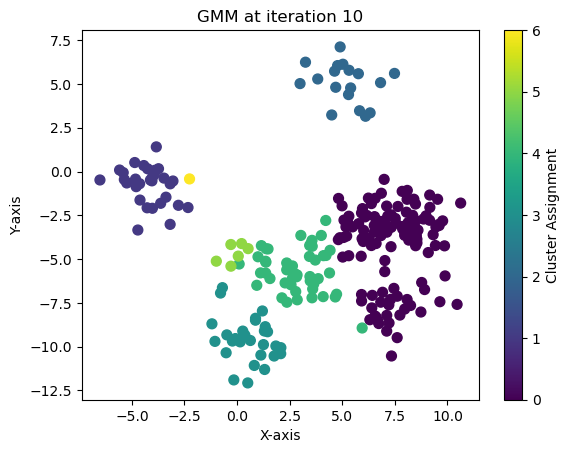

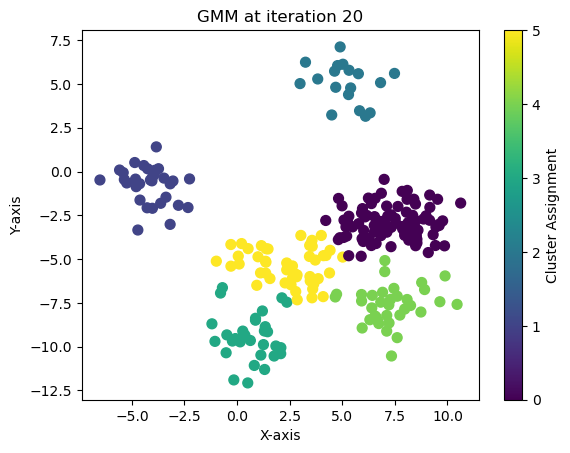

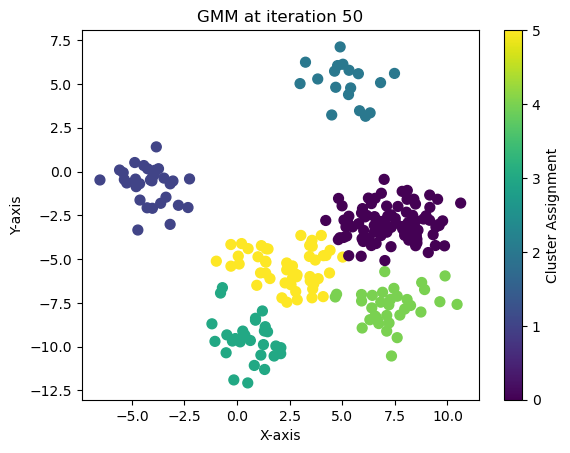

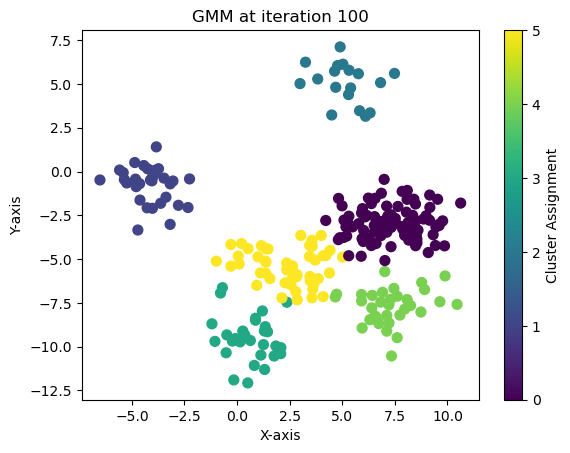

In [39]:
np.random.seed(17) # for reproducibility
# Snapshots of parameters
snapshots = [1, 4, 5, 10, 30, 50]
# Run Collapsed Gibbs Sampling
clusters = np.array([0] * N)
for idx, itr in enumerate(snapshots):
    for i in range(itr):
        clusters = collapsed_gibbs(x, alpha_hat, var_hat, mu0, tau0, N, clusters)
    # Visualize the current state
    visualize(x, clusters, sum(snapshots[:idx+1]))

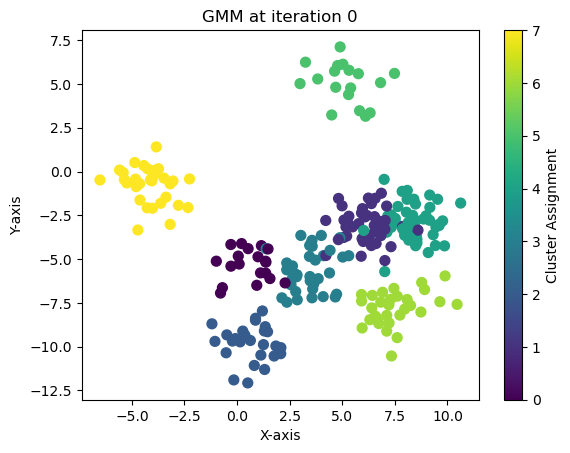

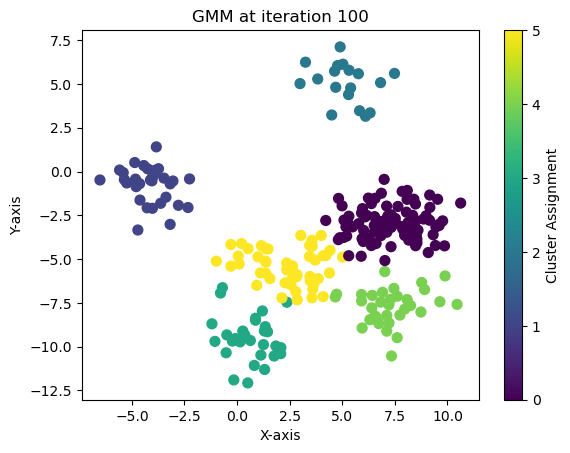

In [40]:
visualize(x, z, 0)
visualize(x, clusters, sum(snapshots))